# EDA — `customers.csv`: does the customer file change the time-to-payment verdict?

**Where we left off (`products.ipynb`).** The delinquent credit book is sizeable (18,765 products,
17,650 customers), but `products.csv` cannot support a time-to-payment model: it has no payment
target, no history, and its features show no relation to delinquency.

**Questions for this notebook.**

1. Does `customers.csv` join cleanly to the products, and is it trustworthy?
2. Do customer attributes (credit score, income, age, segment...) explain who is delinquent? If
   yes, that would be the signal `products.csv` lacked.
3. Does it change the *size* or the *actionability* of the opportunity (who to call first, and
   can we reach them)?

Scope: descriptive only, no model. Nothing is imputed or invented. The file contains personal data
(names, emails, phones, addresses, documents), so **no row-level customer data is displayed** in
this notebook, only aggregates.

## 1. Setup and load

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.2f}".format)

REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
DATA_DIRECTORY = REPO_ROOT / "data" / "data"

BAR_COLOR = "#2E6DB4"
MUTED_COLOR = "#6B7280"

customers = pd.read_csv(
    DATA_DIRECTORY / "customers.csv",
    dtype={"document_number": str, "postal_code": str},
    parse_dates=["date_of_birth", "registration_date", "last_updated"],
)
products = pd.read_csv(
    DATA_DIRECTORY / "products.csv",
    parse_dates=["opening_date", "expiration_date", "last_transaction_date", "last_updated"],
)
REFERENCE_DATE = products["last_transaction_date"].max().normalize()
customers.shape, products.shape

((150000, 27), (400000, 17))

## 2. Structure and data quality

In [2]:
schema = pd.DataFrame(
    {
        "dtype": customers.dtypes.astype(str),
        "missing_pct": customers.isna().mean() * 100,
        "distinct": customers.nunique(),
    }
)
display(schema)
display(pd.Series({
    "rows": len(customers),
    "duplicate customer_id": customers["customer_id"].duplicated().sum(),
    "duplicate document_number": customers["document_number"].duplicated().sum(),
}, name="count").to_frame())

,dtype,missing_pct,distinct
customer_id,str,0.00,150000
document_number,str,0.00,150000
document_type,str,0.00,4
first_name,str,0.00,7480
last_name,str,0.00,3460
date_of_birth,datetime64[us],0.00,22956
gender,str,0.00,3
email,str,1.99,91289
mobile_phone,str,3.14,145285
landline_phone,str,50.04,74942


,count
rows,150000
duplicate customer_id,0
duplicate document_number,0


The identifiers are clean, and `credit_score` (15% missing) and `estimated_monthly_income` (20%
missing) are the only analytically important gaps. Missing values are kept as missing.

### Contact data quality

For collections, the point of this file is *reaching* people, so the quality of phone and email
matters more than their presence.

In [3]:
EXPECTED_PHONE_PREFIX_BY_COUNTRY = {"México": "+52", "Colombia": "+57", "Argentina": "+54"}

mobile_prefix = customers["mobile_phone"].str.extract(r"^(\+\d+)")[0]
expected_prefix = customers["country"].map(EXPECTED_PHONE_PREFIX_BY_COUNTRY)
has_mobile = customers["mobile_phone"].notna()

display(pd.crosstab(customers["country"], mobile_prefix.fillna("no mobile"), margins=True))

prefix_matches = (mobile_prefix == expected_prefix)[has_mobile]
email_counts = customers["email"].dropna().value_counts()
shared_email_rows = customers["email"].dropna().map(email_counts).gt(1)

display(pd.Series({
    "customers with a mobile phone": has_mobile.sum(),
    "mobile prefix consistent with the customer's country": prefix_matches.sum(),
    "mobile prefix NOT consistent with the country": (~prefix_matches).sum(),
    "customers with an email": customers["email"].notna().sum(),
    "emails shared by more than one customer (distinct addresses)": (email_counts > 1).sum(),
    "customers whose email is shared with another customer": shared_email_rows.sum(),
    "max customers on a single email": email_counts.max(),
    "mobile numbers shared by more than one customer": customers["mobile_phone"].dropna().duplicated().sum(),
}, name="count").to_frame())

,+54,+57,no mobile,All
country,,,,
Argentina,28897,0,945,29842
Colombia,0,43848,1403,45251
México,72548,0,2359,74907
All,101445,43848,4707,150000


,count
customers with a mobile phone,145293
mobile prefix consistent with the customer's country,72745
mobile prefix NOT consistent with the country,72548
customers with an email,147016
emails shared by more than one customer (distinct addresses),24203
customers whose email is shared with another customer,79930
max customers on a single email,31
mobile numbers shared by more than one customer,8


**Reading this.** Colombian numbers carry +57, but **every Mexican customer's mobile carries +54
(Argentina's code)** and none carries +52. Mexican numbers therefore cannot be dialled as recorded.
And more than half of the emails are shared by several customers (up to 31 on one address), so an
email is not a reliable identifier of a person. Presence of contact data overstates real
reachability.

### Other consistency checks

In [4]:
customer_products = products.merge(
    customers[["customer_id", "country", "registration_date", "registration_branch_id"]], on="customer_id"
)
display(pd.crosstab(customer_products["country"], customer_products["currency"], normalize="index") * 100)
display(pd.Series({
    "products opened before the customer's registration_date":
        (customer_products["opening_date"] < customer_products["registration_date"].dt.normalize()).sum(),
    "products opened at the customer's registration branch":
        (customer_products["opening_branch_id"] == customer_products["registration_branch_id"]).sum(),
    "customers already 17 or younger at registration":
        ((customers["registration_date"] - customers["date_of_birth"]).dt.days / 365.25 < 18).sum(),
    f"customers.last_updated after {REFERENCE_DATE.date()}": (customers["last_updated"] > REFERENCE_DATE).sum(),
}, name="count").to_frame())

currency,ARS,COP,USD
country,,,
Argentina,90.03,0.00,9.97
Colombia,0.00,89.86,10.14
México,0.00,0.00,100.00


,count
products opened before the customer's registration_date,199596
products opened at the customer's registration branch,0
customers already 17 or younger at registration,3831
customers.last_updated after 2026-06-17,9379


About half of all products were **opened before the owner's registration date**, and no product
was ever opened at the branch where its owner registered. `last_updated` again runs past the
snapshot. Two consequences: relationships across the two files are not chronologically coherent,
and **Mexican customers hold only USD products** (no MXN), while Argentine and Colombian customers
hold ~90% local currency and ~10% USD. Income is presumably in local currency (its scale differs by
country by orders of magnitude), which is not the currency of Mexican customers' products, so a
debt-to-income ratio cannot be computed honestly here.

## 3. Customer profile

In [5]:
for column in ["segment", "customer_status", "country", "document_type", "gender", "marital_status",
               "education_level", "accepts_marketing"]:
    display(customers[column].value_counts(dropna=False).to_frame(column))
display(customers.groupby("segment")[["credit_score", "estimated_monthly_income"]].median())
display(customers.groupby("country")["estimated_monthly_income"].describe())
display(customers[["credit_score"]].describe())

,segment
segment,
Basic,89756
Plus,37547
Premium,15207
Student,7490


,customer_status
customer_status,
Active,127700
Inactive,14914
Suspended,4407
Closed,2979


,country
country,
México,74907
Colombia,45251
Argentina,29842


,document_type
document_type,
DNI,104749
CE,15150
Pasaporte,15062
CC,15039


,gender
gender,
F,50508
O,49808
M,49684


...

,education_level
education_level,
College Prep,39583
High School,33120
University,32870
NaN,17952
Graduate,13269
Elementary,13206


,accepts_marketing
accepts_marketing,
False,75007
True,74993


,credit_score,estimated_monthly_income
segment,,
Basic,600.00,"282,786.89"
Plus,699.00,"177,995.40"
Premium,799.00,"474,215.88"
Student,649.00,"119,008.62"


,count,mean,std,min,25%,50%,75%,max
country,,,,,,,,
Argentina,"23,864.00","1,609,498.26","1,898,182.81","105,127.04","512,732.97","801,955.38","2,087,355.90","9,796,686.17"
Colombia,"36,135.00","18,380,719.44","21,651,241.11","1,200,127.28","5,855,823.97","9,192,465.52","24,008,281.64","111,895,075.15"
México,"59,968.00","78,782.93","92,797.24","5,100.28","24,995.91","39,219.57","102,205.82","475,981.74"


,credit_score
count,"127,508.00"
mean,647.10
std,76.85
min,422.00
25%,591.00
50%,631.00
75%,695.00
max,850.00


`segment` is meaningfully tied to `credit_score` (medians of 600 / 649 / 699 / 799 for Basic /
Student / Plus / Premium), and income is only weakly related to score. Occupations are almost
perfectly evenly distributed (~6,700 each) and genders and marital statuses are also uniform, which
is unusual for a real population. Income is in unspecified local units, so it is only comparable
within a country.

## 4. Join with products

In [6]:
credit = products[products["days_past_due"].notna()].copy()
credit["is_delinquent"] = credit["days_past_due"] > 0
delinquent = credit[credit["is_delinquent"]]

customer_credit = credit.groupby("customer_id").agg(
    credit_products=("product_id", "size"),
    delinquent_products=("is_delinquent", "sum"),
    worst_days_past_due=("days_past_due", "max"),
).reset_index()
customer_credit["is_delinquent_customer"] = customer_credit["delinquent_products"] > 0
credit_customers = customer_credit.merge(customers, on="customer_id", how="left", validate="one_to_one")

display(pd.Series({
    "customers in customers.csv": len(customers),
    "customers with at least one product": products["customer_id"].nunique(),
    "product customers missing from customers.csv": (~products["customer_id"].isin(customers["customer_id"])).sum(),
    "customers without any product": (~customers["customer_id"].isin(products["customer_id"])).sum(),
    "customers with credit products (days_past_due known)": len(customer_credit),
    "delinquent customers": customer_credit["is_delinquent_customer"].sum(),
    "delinquent customers as % of credit customers": customer_credit["is_delinquent_customer"].mean() * 100,
}, name="value").to_frame())

,value
customers in customers.csv,"150,000.00"
customers with at least one product,"139,578.00"
product customers missing from customers.csv,0.00
customers without any product,"10,422.00"
customers with credit products (days_past_due known),"84,926.00"
delinquent customers,"17,650.00"
delinquent customers as % of credit customers,20.78


The join is clean: every customer that owns a product exists in `customers.csv`, one-to-one.
The 10,422 customers without any product are irrelevant to collections.

## 5. Do customer attributes explain who is delinquent?

This is the decisive question. `products.csv` had no signal. If credit score, income, age or
segment separated delinquent from non-delinquent customers, that would be a route to prioritisation
without a payments ledger. Same method as before: if a feature carries signal, the delinquency rate
must differ between its segments.

In [7]:
def delinquency_rate_by_segment(frame: pd.DataFrame, segment: pd.Series, label: str) -> pd.DataFrame:
    """Computes the share of delinquent customers within each segment of one attribute.

    Exists so every customer attribute is compared on identical terms against the overall rate.

    Args:
        frame: Credit customers with the is_delinquent_customer flag.
        segment: Segment assignment aligned to frame's index.
        label: Attribute name shown in the output.

    Returns:
        pd.DataFrame: one row per segment with attribute, segment, customers and delinquent rate (%).
    """
    grouped = frame["is_delinquent_customer"].groupby(segment, observed=True).agg(["mean", "size"])
    return pd.DataFrame({
        "attribute": label,
        "segment": grouped.index.astype(str),
        "customers": grouped["size"].to_numpy(),
        "delinquent_rate_pct": grouped["mean"].to_numpy() * 100,
    })


age_years = (REFERENCE_DATE - credit_customers["date_of_birth"]).dt.days / 365.25
segments = {
    "segment": credit_customers["segment"],
    "customer_status": credit_customers["customer_status"],
    "country": credit_customers["country"],
    "gender": credit_customers["gender"],
    "marital_status": credit_customers["marital_status"].fillna("missing"),
    "education_level": credit_customers["education_level"].fillna("missing"),
    "occupation": credit_customers["occupation"].fillna("missing"),
    "document_type": credit_customers["document_type"],
    "accepts_marketing": credit_customers["accepts_marketing"],
    "credit_score band": pd.cut(credit_customers["credit_score"], [0, 500, 600, 700, 800, 900]).astype(str)
        .where(credit_customers["credit_score"].notna(), "missing"),
    "income quintile (within country)": credit_customers.groupby("country")["estimated_monthly_income"]
        .transform(lambda s: pd.qcut(s, 5, labels=False) + 1).fillna(0).astype(int).astype(str),
    "age band": pd.cut(age_years, [0, 25, 35, 45, 55, 65, 120]).astype(str),
}
segment_rates = pd.concat(
    [delinquency_rate_by_segment(credit_customers, values, name) for name, values in segments.items()],
    ignore_index=True,
)
overall_rate = credit_customers["is_delinquent_customer"].mean() * 100
display(segment_rates.groupby("attribute")["delinquent_rate_pct"].agg(["min", "max"]).assign(spread=lambda t: t["max"] - t["min"]))
overall_rate

,min,max,spread
attribute,,,
accepts_marketing,20.59,20.97,0.38
age band,20.44,21.21,0.77
country,20.69,20.93,0.24
credit_score band,20.58,21.95,1.38
customer_status,20.51,20.85,0.34
document_type,20.67,21.23,0.55
education_level,19.85,21.32,1.47
gender,20.76,20.81,0.06
income quintile (within country),20.28,21.29,1.01


np.float64(20.78279914278313)

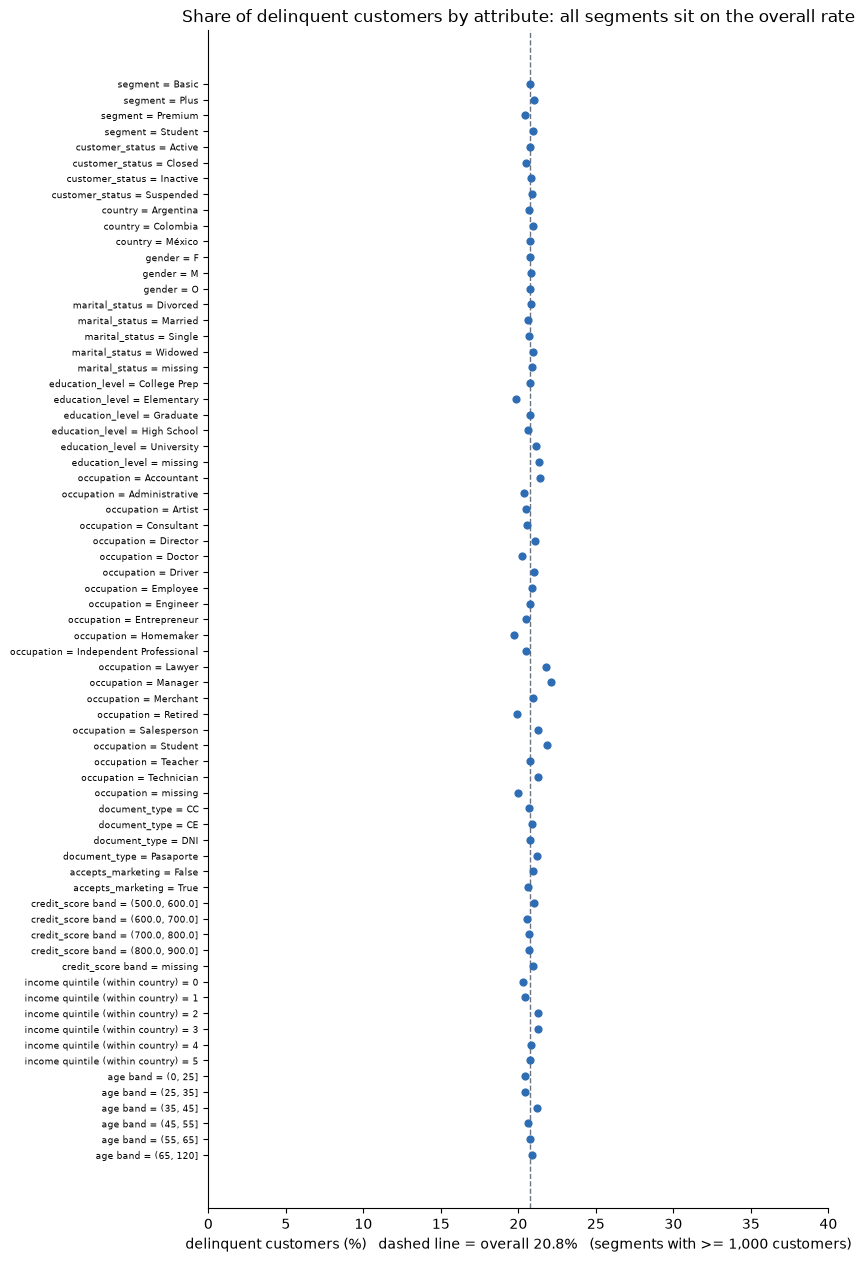

In [8]:
plot_frame = segment_rates[segment_rates["customers"] >= 1000].iloc[::-1].reset_index(drop=True)
fig, ax = plt.subplots(figsize=(8, 0.2 * len(plot_frame) + 1.5))
ax.axvline(overall_rate, color=MUTED_COLOR, linewidth=1, linestyle="--")
ax.scatter(plot_frame["delinquent_rate_pct"], plot_frame.index, s=24, color=BAR_COLOR, zorder=3)
ax.set_yticks(plot_frame.index)
ax.set_yticklabels(plot_frame["attribute"] + " = " + plot_frame["segment"], fontsize=6.5)
ax.set_xlim(0, 40)
ax.set_xlabel(f"delinquent customers (%)   dashed line = overall {overall_rate:.1f}%   (segments with >= 1,000 customers)")
ax.set_title("Share of delinquent customers by attribute: all segments sit on the overall rate")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

In [9]:
numeric_view = credit_customers.assign(age_years=age_years)[
    ["worst_days_past_due", "credit_score", "estimated_monthly_income", "age_years"]
]
display(numeric_view.corr(method="spearman")[["worst_days_past_due"]].rename(
    columns={"worst_days_past_due": "spearman_with_worst_days_past_due"}
))
delinquent_only = credit_customers[credit_customers["is_delinquent_customer"]]
display(delinquent_only.groupby("worst_days_past_due")[["credit_score", "estimated_monthly_income"]].median())

,spearman_with_worst_days_past_due
worst_days_past_due,1.00
credit_score,-0.01
estimated_monthly_income,0.00
age_years,0.00


,credit_score,estimated_monthly_income
worst_days_past_due,,
15.00,629.00,"318,428.39"
30.00,630.00,"300,772.05"
60.00,631.00,"304,488.26"
90.00,632.00,"423,414.13"
120.00,630.00,"386,730.80"
180.00,628.00,"333,052.37"


### Number of credit products is not an attribute, it is exposure

A customer is delinquent if *any* of their credit products is. More products means more chances,
so the customer-level rate rises with product count even if every product had the same, independent
risk. Comparing with the independence expectation (using the overall product-level rate) shows
whether product count adds anything beyond that.

In [10]:
product_delinquency_rate = credit["is_delinquent"].mean()
by_product_count = credit_customers.assign(
    credit_products_held=credit_customers["credit_products"].clip(upper=4)
).groupby("credit_products_held").agg(
    customers=("customer_id", "size"),
    observed_delinquent_pct=("is_delinquent_customer", lambda s: s.mean() * 100),
)
by_product_count["expected_if_independent_pct"] = (
    1 - (1 - product_delinquency_rate) ** by_product_count.index.to_series()
) * 100
display(by_product_count)

,customers,observed_delinquent_pct,expected_if_independent_pct
credit_products_held,,,
1,54296,14.79,14.97
2,22693,28.18,27.70
3,6364,38.61,38.52
4,1573,48.76,47.73


**Result: no signal.** Every segment of every customer attribute above sits within about two
percentage points of the overall rate (the widest spread is occupation, 2.4 points, across small
groups), including credit score, which in real portfolios is the
single most predictive attribute. Rank correlations between the worst `days_past_due` and score,
income and age are ~0, and among delinquent customers the median score and income are flat across
`days_past_due` levels. Adding the customer file gives us **no** predictive signal for
delinquency, and by extension nothing to work with for how long it lasts.

## 6. What the customer file does add: who is worth calling, and can we reach them

Even without a predictive model, `customers.csv` supports *operational* prioritisation. Each
piece below is descriptive and uses only recorded fields.

### 6a. Status of delinquent customers

In [11]:
delinquent_customers = customer_credit[customer_credit["is_delinquent_customer"]].merge(customers, on="customer_id")
display(delinquent_customers["customer_status"].value_counts().to_frame("delinquent_customers"))
display(delinquent_customers["segment"].value_counts().to_frame("delinquent_customers"))

,delinquent_customers
customer_status,
Active,15048
Inactive,1762
Suspended,505
Closed,335


,delinquent_customers
segment,
Basic,10531
Plus,4480
Premium,1756
Student,883


### 6b. Concentration: how much of the delinquent balance sits in how few customers

If a small share of customers holds most of the money, a value-ordered work list captures much of
the exposure without any prediction. This is per currency (no FX rates) and uses total balance on
delinquent products, not overdue amounts.

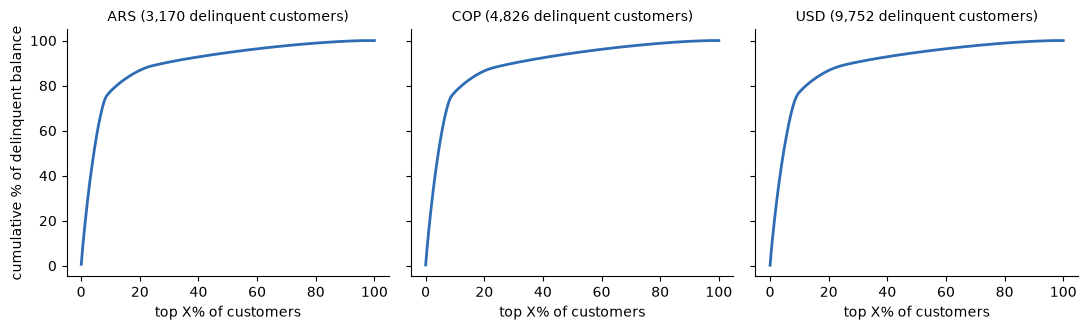

,top 1% of customers hold (% of balance),top 10% of customers hold (% of balance),top 20% of customers hold (% of balance)
ARS,14.39,77.47,86.79
COP,14.66,77.12,86.52
USD,14.23,77.07,86.73


In [12]:
exposure_per_customer = (
    delinquent.groupby(["currency", "customer_id"])["current_balance"].sum().reset_index()
)


def cumulative_balance_share(balances: pd.Series) -> pd.DataFrame:
    """Builds the cumulative share of balance held by the largest customers.

    Exists to show how concentrated the delinquent exposure is for one currency.

    Args:
        balances: Delinquent balance per customer for a single currency.

    Returns:
        pd.DataFrame: share of customers (largest first) against cumulative share of balance.
    """
    ordered = balances.sort_values(ascending=False).reset_index(drop=True)
    return pd.DataFrame({
        "customer_share": (ordered.index + 1) / len(ordered),
        "balance_share": ordered.cumsum() / ordered.sum(),
    })


concentration_rows = []
fig, axes = plt.subplots(1, 3, figsize=(11, 3.4), sharey=True)
for axis, (currency, group) in zip(axes, exposure_per_customer.groupby("currency")):
    curve = cumulative_balance_share(group["current_balance"])
    axis.plot(curve["customer_share"] * 100, curve["balance_share"] * 100, color=BAR_COLOR, linewidth=2)
    axis.set_title(f"{currency} ({len(group):,} delinquent customers)", fontsize=10)
    axis.set_xlabel("top X% of customers")
    axis.spines[["top", "right"]].set_visible(False)
    top_shares = {
        f"top {share}%": curve.loc[curve["customer_share"] <= share / 100, "balance_share"].iloc[-1] * 100
        for share in (1, 10, 20)
    }
    concentration_rows.append(pd.Series(top_shares, name=currency))
axes[0].set_ylabel("cumulative % of delinquent balance")
plt.tight_layout()
plt.show()
display(pd.DataFrame(concentration_rows).add_suffix(" of customers hold (% of balance)"))

**What drives the concentration?** The knee in the curves sits near 10% of customers. Checking by
product type:

In [13]:
balance_by_type = delinquent.groupby(["currency", "product_type"])["current_balance"].sum()
type_summary = pd.DataFrame({
    "delinquent_products": delinquent.groupby(["currency", "product_type"]).size(),
    "share_of_currency_balance_pct": balance_by_type / balance_by_type.groupby("currency").transform("sum") * 100,
})
display(type_summary)
display((delinquent["product_type"].value_counts(normalize=True) * 100).to_frame("share_of_delinquent_products_pct"))

delinquent_products  share_of_currency_balance_pct
currency product_type                                                            
ARS      Préstamo Hipotecario                  292                          75.41
         Préstamo Personal                     515                          12.91
         Tarjeta Crédito                      2535                          11.68
COP      Préstamo Hipotecario                  445                          75.23
         Préstamo Personal                     749                          12.33
         Tarjeta Crédito                      3891                          12.44
USD      Préstamo Hipotecario                  986                          76.19
         Préstamo Personal                    1576                          12.36
         Tarjeta Crédito                      7776                          11.45

,share_of_delinquent_products_pct
product_type,
Tarjeta Crédito,75.68
Préstamo Personal,15.13
Préstamo Hipotecario,9.18


Mortgages are ~9% of delinquent products but hold ~75% of the delinquent balance in every
currency. The concentration is therefore mostly **loan size (mortgages)**, which means the
value-ordered list is largely a "call the mortgage holders first" list.

### 6c. Reachability of delinquent customers (as recorded)

Presence is easy to count; the checks in section 2 say quality is lower than presence suggests.

In [14]:
delinquent_contact = delinquent_customers.assign(
    has_mobile=delinquent_customers["mobile_phone"].notna(),
    mobile_prefix_valid=(
        delinquent_customers["mobile_phone"].str.extract(r"^(\+\d+)")[0]
        == delinquent_customers["country"].map(EXPECTED_PHONE_PREFIX_BY_COUNTRY)
    ),
    has_email=delinquent_customers["email"].notna(),
    email_shared=delinquent_customers["email"].map(email_counts).gt(1),
    has_landline=delinquent_customers["landline_phone"].notna(),
)
contact_summary = pd.Series({
    "has a mobile number": delinquent_contact["has_mobile"].mean() * 100,
    "mobile number with a prefix valid for their country": delinquent_contact["mobile_prefix_valid"].mean() * 100,
    "has an email": delinquent_contact["has_email"].mean() * 100,
    "has an email that is NOT shared with another customer":
        (delinquent_contact["has_email"] & ~delinquent_contact["email_shared"]).mean() * 100,
    "has a landline": delinquent_contact["has_landline"].mean() * 100,
    "usable mobile or unshared email":
        (delinquent_contact["mobile_prefix_valid"]
         | (delinquent_contact["has_email"] & ~delinquent_contact["email_shared"])).mean() * 100,
}, name="% of delinquent customers")
display(contact_summary.to_frame())
display(delinquent_contact.groupby("country")[["mobile_prefix_valid", "has_landline"]].mean().mul(100))

,% of delinquent customers
has a mobile number,96.88
mobile number with a prefix valid for their country,48.48
has an email,98.01
has an email that is NOT shared with another customer,45.38
has a landline,49.62
usable mobile or unshared email,70.74


,mobile_prefix_valid,has_landline
country,,
Argentina,96.54,49.97
Colombia,97.08,49.80
México,0.00,49.37


**Where is the reachability gap?** The same checks by country, in counts, to see which customers a contact-data repair would affect.

In [15]:
usable_email = delinquent_contact["has_email"] & ~delinquent_contact["email_shared"]
delinquent_by_country = delinquent_contact.assign(
    usable_email=usable_email,
    usable_mobile_or_email=delinquent_contact["mobile_prefix_valid"] | usable_email,
).groupby("country").agg(
    delinquent_customers=("customer_id", "size"),
    with_a_mobile=("has_mobile", "sum"),
    with_a_valid_prefix_mobile=("mobile_prefix_valid", "sum"),
    with_an_unshared_email=("usable_email", "sum"),
    with_a_usable_mobile_or_email=("usable_mobile_or_email", "sum"),
)
delinquent_by_country.loc["Total"] = delinquent_by_country.sum()
display(delinquent_by_country)
display((delinquent_by_country.div(delinquent_by_country["delinquent_customers"], axis=0) * 100).round(1).drop(columns="delinquent_customers"))

,delinquent_customers,with_a_mobile,with_a_valid_prefix_mobile,with_an_unshared_email,with_a_usable_mobile_or_email
country,,,,,
Argentina,3494,3373,3373,1751,3430
Colombia,5339,5183,5183,2454,5251
México,8817,8544,0,3804,3804
Total,17650,17100,8556,8009,12485


,with_a_mobile,with_a_valid_prefix_mobile,with_an_unshared_email,with_a_usable_mobile_or_email
country,,,,
Argentina,96.50,96.50,50.10,98.20
Colombia,97.10,97.10,46.00,98.40
México,96.90,0.00,43.10,43.10
Total,96.90,48.50,45.40,70.70


Argentina and Colombia customers have a valid-prefix mobile almost whenever they have a mobile at all. **Mexico has none** (every Mexican mobile carries +54), and that is where the gap between "has a mobile" and "has a mobile with a valid prefix" sits. The column `with_a_mobile` is the ceiling if the prefixes were correctable, which this data cannot confirm (the digits themselves may also be wrong).

Delinquent balance (total balance on delinquent products, per currency, no FX) by the **customer's country**. Mexican customers hold only USD products, so their share of the USD delinquent balance is the money behind the Mexican contact gap.

In [16]:
balance_by_customer_country = (
    delinquent.merge(customers[["customer_id", "country"]], on="customer_id")
    .groupby(["country", "currency"])["current_balance"].sum().unstack("currency")
)
display(balance_by_customer_country)
display((balance_by_customer_country / balance_by_customer_country.sum() * 100).round(1))

currency,ARS,COP,USD
country,,,
Argentina,"11,401,471,219.03",NaN,"2,875,848.02"
Colombia,NaN,"188,935,509,727.34","5,246,528.03"
México,NaN,NaN,"93,858,941.54"


currency,ARS,COP,USD
country,,,
Argentina,100.00,NaN,2.80
Colombia,NaN,100.00,5.10
México,NaN,NaN,92.00


### 6d. Do delinquent customers hold funds with the bank?

A customer who owes on a credit product but keeps balance in an `Active` savings or checking account
in the same currency is a different collections conversation from one with no relationship
elsewhere. This shows what is *recorded*. It says nothing about whether those funds are available or
whether the bank may use them.

In [17]:
DEPOSIT_PRODUCT_TYPES = ["Cuenta Ahorro", "Cuenta Corriente"]

active_deposits = products[
    products["product_type"].isin(DEPOSIT_PRODUCT_TYPES) & (products["product_status"] == "Active")
]
deposit_balance = (
    active_deposits.groupby(["customer_id", "currency"])["current_balance"].sum().rename("deposit_balance")
)
owed = delinquent.groupby(["customer_id", "currency"])["current_balance"].sum().rename("delinquent_balance")
funds_view = owed.to_frame().join(deposit_balance).reset_index()
funds_view["has_active_deposit_same_currency"] = funds_view["deposit_balance"].notna()
funds_view["deposit_covers_delinquent_balance"] = funds_view["deposit_balance"] >= funds_view["delinquent_balance"]

by_currency = funds_view.groupby("currency").agg(
    delinquent_customer_currency_pairs=("customer_id", "size"),
    with_active_deposit=("has_active_deposit_same_currency", "sum"),
    deposit_covers_balance=("deposit_covers_delinquent_balance", "sum"),
    delinquent_balance=("delinquent_balance", "sum"),
)
by_currency["delinquent_balance_of_covered"] = funds_view[funds_view["deposit_covers_delinquent_balance"]].groupby(
    "currency"
)["delinquent_balance"].sum()
display(by_currency)
display(pd.Series({
    "delinquent customers with any Active deposit account (any currency)":
        delinquent["customer_id"].drop_duplicates().isin(active_deposits["customer_id"]).sum(),
    "delinquent customers": delinquent["customer_id"].nunique(),
}, name="value").to_frame())

,delinquent_customer_currency_pairs,with_active_deposit,deposit_covers_balance,delinquent_balance,delinquent_balance_of_covered
currency,,,,,
ARS,3170,2126,1564,"11,401,471,219.03","959,690,515.65"
COP,4826,3260,2420,"188,935,509,727.34","17,605,803,479.57"
USD,9752,6434,4707,"101,981,317.59","8,718,156.10"


,value
delinquent customers with any Active deposit account (any currency),12625
delinquent customers,17650


## 7. Conclusions

**Did the customer file change the verdict on the time-to-payment model? No.**

- **Still no target.** `customers.csv` has no payments, due dates or collection history either.
  Time-to-payment cannot be defined from these two files together.
- **Still no signal.** The delinquent-customer share is ~20.8% in every segment of every attribute,
  including credit score, income, age, segment and status, and the worst `days_past_due` is
  uncorrelated with them. In real portfolios credit score and income are the strongest levers; here
  they show none. Taken with the products result (uniform 15% delinquency, only seven
  `days_past_due` values), the two files look like independently generated tables in which
  delinquency was assigned at random. I cannot prove that, but there is nothing in the data that
  would let a model learn who pays sooner.
- **Data reliability problems** that would matter in production: Mexican mobiles all carry
  Argentina's +54; more than half of the emails are shared by several customers; ~50% of
  products predate their owner's registration; Mexican customers hold only USD products; timestamps
  run past the snapshot date.

**What the customer file does add (operational, no model needed):**

- **The opportunity is real in size and the cash is concentrated.** In each currency, roughly the
  top 10% of delinquent customers hold about three quarters of the delinquent balance (see 6b
  for the exact figures), and this is mostly mortgages (~9% of delinquent products, ~75% of the
  balance). A work list ordered by balance already targets most of the money. This is
  concentration in balance, not evidence about who pays sooner.
- **Most delinquent customers are workable on paper, fewer in practice.** 15,048 of the 17,650
  are `Active` customers. 96.9% have a mobile and 98.0% an email on file, but only 48.5% have a
  mobile with a prefix valid for their country (0% in Mexico) and 45.4% have an email not shared
  with another customer. About 70.7% have at least one usable channel by those checks. Measure
  real contact rates before promising a workforce gain.
- **Many delinquent customers hold funds with the bank, but not where the money is.** 12,625
  of 17,650 have an `Active` deposit account. In about half of the customer-currency pairs the
  same-currency deposit balance covers the whole delinquent balance, but those cases hold only
  ~8-9% of the delinquent balance in each currency (the large exposures are not covered). A
  potential lever, subject to legal and product rules this data cannot tell us.

**Bottom line for the project.** There is money at stake, but this data pair cannot tell us *who
will pay soon*. The honest first step is not a model. It is (1) getting the payment ledger and
collection-action history, (2) fixing contact data and currency/FX issues, and (3) running a
simple experiment on the value-ordered work list to measure how much cash actually moves. Model
work becomes worth discussing only once real payment timing data show that behaviour differs
between customers.